# Investigación Operativa

# PuLP es una librería de Python para formular y resolver problemas de optimización lineal y entera.

#Variables de desición  

Programación lineal (LP)    ->  Variables de desición contínuas  
Programación entera (IP)    ->  Variables de desición discretas o enteras  
Programación entera mixta (MIP)  ->  Variables de desición mezcla de contínuas y enteras

# Softwares más usados


1. **IBM ILOG CPLEX**

2. **Gurobi Optimizer**

3. **Microsoft Excel (Solver)**

4. **MATLAB**

5. **LINDO/LINGO**

6. **R (lpSolve, Rglpk)**

7. **Python (SciPy, Pyomo, PuLP)**


# Pulp

PuLP es una biblioteca de Python utilizada para formular y resolver problemas de programación lineal (LP) y programación entera (IP).  
  
  
Aunque PuLP usa su solver (CBC), también se puede integrar fácilmente con otros solvers como CPLEX, Gurobi y COIN-OR.



---



# Ejemplo:

Ciertos productos granulados deben ser enviados, el precio de cada producto se mide en $/kg, a su vez el vehículo que transporta las cargas tiene un límite de peso.

# Instalamos la librería

In [ ]:
pip install pulp

# Importamos la librería

In [ ]:
from pulp import *


##Inicializamos el modelo

Creamos la clase:
#modelo = LpProblem(name, sense)
  
    

name = nombre del problema

sense = objetivo de la función

>>Minimizar = LpMinimize

>>Maximizar = LpMaximize

In [ ]:
# Se inicializa la clase

modelo = LpProblem(name='Primer_modelo', sense=LpMaximize)

## Definimos las variables de desición

# LpVariable(name, lowBound, upBound, cat, e)

name = Nombre de la variable usada en la salida

lowBound = Límite inferior

upBound = Límite superior

cat = El tipo de variable, osea:
* Integer (entero)

* Binary (binario)

* Continuous (contínua)

e = no lo vemos


In [ ]:
# Se definen la variables de desición

X1 = LpVariable('X1', lowBound=0, cat='Continuous')
X2 = LpVariable('X2', lowBound=0, cat='Continuous')

# Definimos la función Objetivo

In [ ]:
# Funcional

modelo += 20 * X1 + 40 * X2

# Definimos las restricciones

In [ ]:
# Restricciones

modelo += 0.5 * X1 +   1 * X2 <= 30
modelo +=   1 * X1 + 2.5 * X2 <= 60
modelo +=   1 * X1 +   2 * X2 <= 22

# Resolvemos el modelo

In [ ]:
# Solución del modelo

modelo.solve()

1

# Mostramos los resultados

In [ ]:
print(f'Se deben producir {X1.varValue} unidades de X1')
print(f'Se deben producir {X2.varValue} unidades de X2')

Se deben producir 0.0 unidades de X1
Se deben producir 0.0 unidades de X2


# Código completo

In [ ]:
# Se inicializa la clase
modelo = LpProblem(name='Primer_modelo', sense=LpMaximize)

# Se definen la variables de desición
X1 = LpVariable('X1', lowBound=0, cat='Continuous')
X2 = LpVariable('X2', lowBound=0, cat='Continuous')

# Funcional
modelo += 20 * X1 + 40 * X2

# Restricciones
modelo += 0.5 * X1 +   1 * X2 >= 30
modelo +=   1 * X1 + 2.5 * X2 <= 60
modelo +=   1 * X1 +   2 * X2 <= 22

# Solución del modelo
modelo.solve()

print(f'Se deben producir {X1.varValue} unidades de X1')
print(f'Se deben producir {X2.varValue} unidades de X2')
print()
print(f'Valor de la función objetivo es de: ${modelo.objective.value()}')

Se deben producir 60.0 unidades de X1
Se deben producir 0.0 unidades de X2

Valor de la función objetivo es de: $1200.0




---



 ¿pero y si tuvieramos muchas variables?     

 5, 10 ó 200 variables...

 ¿Tenemos que escribir una por una las 200 variables?  


 X1 = LpVariable('X1', lowBound=0, cat='Continuous')

 X2 = LpVariable('X2', lowBound=0, cat='Continuous')

 X3 = LpVariable('X3', lowBound=0, cat='Continuous')

 >>>>> .

 >>>>> .

 >>>>> .





 X200 = LpVariable('X200', lowBound=0, cat='Continuous')


Z = 20 X1 + 40 X2 + 30 X3 +  . . .  + 200 X200

Por ejemplo para 10 variables

In [ ]:
# Crear el modelo
modelo2 = LpProblem("Modelo_2", sense=LpMaximize)

# Definición de variables continuas
X1 = LpVariable('X1', lowBound=0, cat='Continuous')
X2 = LpVariable('X2', lowBound=0, cat='Continuous')
X3 = LpVariable('X3', lowBound=0, cat='Continuous')
X4 = LpVariable('X4', lowBound=0, cat='Continuous')
X5 = LpVariable('X5', lowBound=0, cat='Continuous')
X6 = LpVariable('X6', lowBound=0, cat='Continuous')
X7 = LpVariable('X7', lowBound=0, cat='Continuous')
X8 = LpVariable('X8', lowBound=0, cat='Continuous')
X9 = LpVariable('X9', lowBound=0, cat='Continuous')
X10 = LpVariable('X10', lowBound=0, cat='Continuous')

# Defino la función objetivo
modelo2 += 20 * X1 + 40 * X2 + 30 * X3 + 25 * X4 + 35 * X5 + 50 * X6 + 45 * X7 + 55 * X8 + 60 * X9 + 70 * X10, "Beneficio"

# Agrego restricciones
modelo2 += 0.5 * X1 + 1 * X2 + 1 * X3 + 2 * X4 + 0.5 * X5 + 2 * X6 + 1 * X7 + 2 * X8 + 1 * X9 + 2 * X10 <= 30, "Restriccion"

# Resuelvo
modelo2.solve()

# Mostrar resultados
for variable in [X1, X2, X3, X4, X5, X6, X7, X8, X9, X10]:
    print(f'{variable.name} = {variable.varValue:.0f}')

print()
print(f'Valor de la función objetivo es de: ${modelo2.objective.value()}')


X1 = 0
X2 = 0
X3 = 0
X4 = 0
X5 = 60
X6 = 0
X7 = 0
X8 = 0
X9 = 0
X10 = 0

Valor de la función objetivo es de: $2100.0


In [ ]:
# Mostrar el modelo
print(modelo2)

Modelo_2:
MAXIMIZE
20*X1 + 70*X10 + 40*X2 + 30*X3 + 25*X4 + 35*X5 + 50*X6 + 45*X7 + 55*X8 + 60*X9 + 0
SUBJECT TO
Restriccion: 0.5 X1 + 2 X10 + X2 + X3 + 2 X4 + 0.5 X5 + 2 X6 + X7 + 2 X8 + X9
 <= 30

VARIABLES
X1 Continuous
X10 Continuous
X2 Continuous
X3 Continuous
X4 Continuous
X5 Continuous
X6 Continuous
X7 Continuous
X8 Continuous
X9 Continuous



# Usando LpVariable.dicts()

# LpVariable.dicts(name, indexs, lowBound, upBound, cat)

name = Nombre de la variable usada en la salida

indexs = Lista de cadenas de las claves del diccionario de variables

lowBound = Límite inferior

upBound = Límite superior

cat = El tipo de variable, osea:
* Integer (entero)

* Binary (binario)

* Continuous (contínua)


In [ ]:
# X1 = LpVariable('X1', lowBound=0, cat='Continuous')
# X2 = LpVariable('X2', lowBound=0, cat='Continuous')
# X3 = LpVariable('X3', lowBound=0, cat='Continuous')
# X4 = LpVariable('X4', lowBound=0, cat='Continuous')
# X5 = LpVariable('X5', lowBound=0, cat='Continuous')
# X6 = LpVariable('X6', lowBound=0, cat='Continuous')
# X7 = LpVariable('X7', lowBound=0, cat='Continuous')
# X8 = LpVariable('X8', lowBound=0, cat='Continuous')
# X9 = LpVariable('X9', lowBound=0, cat='Continuous')
# X10 = LpVariable('X10', lowBound=0, cat='Continuous')




P = LpVariable.dicts('P', [1,2,3,4,5,6,7,8,9,10,11,12], lowBound=0, cat='Continuous')

for i in [1,2,3,4,5,6,7,8,9,10,11,12]:
  print(P[i])

P_1
P_2
P_3
P_4
P_5
P_6
P_7
P_8
P_9
P_10
P_11
P_12


In [ ]:
x = LpVariable.dicts('I', list(range(1,20)), lowBound=0, cat='Binary')

for i in range(1,20):
  print(x[i])

I_1
I_2
I_3
I_4
I_5
I_6
I_7
I_8
I_9
I_10
I_11
I_12
I_13
I_14
I_15
I_16
I_17
I_18
I_19


# ¿Si tengo muchos datos de entrada?, ¿tengo que copiar todos?

# lpSum()

lpSum(A list of linear expressions)

* Sirve para sumar muchas variables
* Se usa con comprensión de listas

In [ ]:
precio = [11,9,8,15,12,10,13,11,9,10]

#normalmente
Z1 = 11*x[1] + 9*x[2] + 8*x[3] + 15*x[4] + 12*x[5] + 10*x[6] + 13*x[7] + 11*x[8] + 9*x[9] + 10*x[10]


#con lpSum
Z2 = lpSum(precio[i] * x[i+1] for i in range(10))  #i+1 ?? se puede mejorar??

print(Z1)
print(Z2)

11*I_1 + 10*I_10 + 9*I_2 + 8*I_3 + 15*I_4 + 12*I_5 + 10*I_6 + 13*I_7 + 11*I_8 + 9*I_9
11*I_1 + 10*I_10 + 9*I_2 + 8*I_3 + 15*I_4 + 12*I_5 + 10*I_6 + 13*I_7 + 11*I_8 + 9*I_9


# Reescribo el modelo con lpSum

In [ ]:
# Crear el modelo
modelo3 = LpProblem("Modelo_3", sense=LpMaximize)

productos = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
pesos = [4, 3, 2, 5, 3, 5, 6, 4, 2, 3]
precios = [20, 40, 30, 25, 35, 50, 45, 55, 60, 65]

# Crear variables
X = LpVariable.dicts("X", productos, lowBound=0, cat='Integer')

# Peso máximo permitido
peso_maximo = 30

# Definir la función objetivo
modelo3 += lpSum(precios[i] * X[productos[i]] for i in range(len(productos))), "Beneficio"

# Agregar restricciones
modelo3 += lpSum(pesos[i] * X[productos[i]] for i in range(len(productos))) <= peso_maximo, "Restriccion"

# Resolver el modelo
modelo3.solve()

# Mostrar resultados
for i in range(len(productos)):
    print(f'{productos[i]} = {X[productos[i]].varValue:.0f}')

print()
print(f'Valor de la función objetivo es de: ${modelo3.objective.value()}')



X1 = 0
X2 = 0
X3 = 0
X4 = 0
X5 = 0
X6 = 0
X7 = 0
X8 = 0
X9 = 15
X10 = 0

Valor de la función objetivo es de: $900.0


# Uso de DataFrames

In [ ]:
import pandas as pd

# Cargar el archivo Excel
df = pd.read_excel('datos.xlsx')

df

,precios,pesos
0,20,4
1,40,3
2,30,2
3,25,5
4,35,3
5,50,5
6,45,6
7,55,4
8,60,2
9,65,3


In [ ]:
precio = df['precios']
peso = df['pesos']
peso_maximo = 30

# Crear el modelo
modelo4 = LpProblem("Modelo_4", sense=LpMaximize)

# Definición de variables continuas
X = [LpVariable(f'X{i}', lowBound=0, cat='Continuous') for i in range(1, 11)]

# Definir la función objetivo
modelo4 += lpSum(precio[i] * X[i] for i in range(10)), "Beneficio"

# Agregar restricciones
modelo4 += lpSum(peso[i] * X[i] for i in range(10)) <= peso_maximo, "Restriccion"

# Mostrar el modelo
modelo4.solve()

# Mostrar resultados
for i in range(10):
  print(f'{i} = {X[i].varValue:.0f}')

print()
print(f'Valor de la función objetivo es de: ${modelo4.objective.value()}')

0 = 0
1 = 0
2 = 0
3 = 0
4 = 0
5 = 0
6 = 0
7 = 0
8 = 15
9 = 0

Valor de la función objetivo es de: $900.0


# Uso de diccionarios

In [ ]:
# Crear el modelo
modelo5 = LpProblem("Modelo_5", sense=LpMaximize)

producto = ['X1', 'X2', 'X3', 'X4']
peso = {'X1': 4.2, 'X2': 3.5, 'X3': 2.7, 'X4': 5.1}
beneficio = {'X1': 20.2, 'X2': 40.5, 'X3': 30.7, 'X4': 25.8}
peso_maximo = 30

# Definición de variables continuas
X = LpVariable.dicts('X', producto, lowBound=0, cat='Continuous')

# Definir la función objetivo
modelo5 += lpSum(beneficio[i] * X[i] for i in producto), "Funcional"

# Agregar restricciones
modelo5 += lpSum(peso[i] * X[i] for i in producto) <= peso_maximo, "Restriccion"

# Resolver el modelo
modelo5.solve()

# Mostrar resultados
for i in producto:
    print(f'{i} = {X[i].varValue:.0f}')

print()
print(f'Valor de la función objetivo es de: ${modelo5.objective.value():.2f}')


X1 = 0
X2 = 9
X3 = 0
X4 = 0

Valor de la función objetivo es de: $347.14


# o de mejor manera....

Con variables categóricas

In [ ]:
# Crear el modelo
modelo6 = LpProblem("Modelo_6", sense=LpMaximize)

producto = ['X1', 'X2', 'X3', 'X4']
pesos_lista = [4, 3, 2, 5]
beneficios_lista = [20, 40, 30, 25]
peso_maximo = 30

# Crear diccionarios utilizando zip
peso = dict(zip(producto, pesos_lista))
beneficio = dict(zip(producto, beneficios_lista))

# Definición de variables continuas
X = LpVariable.dicts('X', producto, lowBound=0, cat='Continuous')

# Definir la función objetivo
modelo6 += lpSum(beneficio[i] * X[i] for i in producto), "Funcional"

# Agregar restricciones
modelo6 += lpSum(peso[i] * X[i] for i in producto) <= peso_maximo, "Restriccion"

# Resolver el modelo
modelo6.solve()

# Mostrar resultados
for i in producto:
    print(f'{i} = {X[i].varValue:.0f}')

print(f'\nValor de la función objetivo es de: ${modelo6.objective.value()}')


X1 = 0
X2 = 0
X3 = 15
X4 = 0

Valor de la función objetivo es de: $450.0


# Con variables cualitativas

In [ ]:
# Creo el modelo
modelo7 = LpProblem("Modelo_7", sense=LpMaximize)

# Suponiendo que df ya está definido y contiene las columnas 'beneficio' y 'peso'
precio = df['precios']
peso = df['pesos']
peso_maximo = 30

# Crear diccionarios utilizando zip
peso_dict = dict(zip(range(10), peso))
precio_dict = dict(zip(range(10), precio))

# Definición de variables continuas
X = LpVariable.dicts('X', range(10), lowBound=0, cat='Continuous')

# Definir la función objetivo
modelo7 += lpSum(precio_dict[i] * X[i] for i in range(10)), "Funcional"

# Agregar restricciones
modelo7 += lpSum(peso_dict[i] * X[i] for i in range(10)) <= peso_maximo, "Restriccion"

# Resolver el modelo
modelo7.solve()

# Mostrar resultados
for i in range(10):
    print(f'X{i+1} = {X[i].varValue:.0f}')

print()
print(f'\nValor de la función objetivo es de: ${modelo7.objective.value()}')


X1 = 0
X2 = 0
X3 = 0
X4 = 0
X5 = 0
X6 = 0
X7 = 0
X8 = 0
X9 = 15
X10 = 0


Valor de la función objetivo es de: $900.0




---



#Problema de ditribución  

Hay 2 centros que envían sus productos a 3 fábricas indistintamente. Los centros tienen un límite de producción y la demanda de las fábricas tiene que ser satisfecha. Hay un costo de transporte asociado al envío desde cada centro a cada fábrica

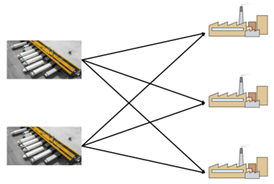

In [ ]:
# Crear el modelo
modelo8 = LpProblem("Distribucion", sense=LpMinimize)

# Definición de variables
centros = ['Centro_1', 'Centro_2']
fabricas = ['Fabrica_A', 'Fabrica_B', 'Fabrica_C']

# Matriz de costos
costos = [
    [4, 6, 8],
    [5, 7, 6]
]

# Demanda de las fábricas
demanda = [20, 30, 25]  # Fábrica_A, Fábrica_B, Fábrica_C

# Capacidad de los centros
capacidad = [50, 60]  # Centro_1, Centro_2

# Definición de variables
x = LpVariable.dicts("x", [(i, j) for i in range(2) for j in range(3)], lowBound=0, cat='Continuous')

# Definir la función objetivo
modelo8 += lpSum(costos[i][j] * x[i, j] for i in range(2) for j in range(3)), "Costo_Total"

# Restricciones de demanda mínima
for j in range(3):
    modelo8 += lpSum(x[i, j] for i in range(2)) >= demanda[j], f"Demanda_{j}"

# Restricciones de capacidad
for i in range(2):
    modelo8 += lpSum(x[i, j] for j in range(3)) <= capacidad[i], f"Capacidad_{i}"

# Resuelvo el modelo
modelo8.solve()

# Mostrar resultados
for i in range(2):
    for j in range(3):
        print(f'Cantidad enviada de {centros[i]} a la {fabricas[j]}: {x[i, j].varValue:.0f}')

print(f'\nCosto total de distribución: ${modelo8.objective.value()}')


Cantidad enviada de Centro_1 a la Fabrica_A: 20
Cantidad enviada de Centro_1 a la Fabrica_B: 30
Cantidad enviada de Centro_1 a la Fabrica_C: 0
Cantidad enviada de Centro_2 a la Fabrica_A: 0
Cantidad enviada de Centro_2 a la Fabrica_B: 0
Cantidad enviada de Centro_2 a la Fabrica_C: 25

Costo total de distribución: $410.0


In [ ]:
print(modelo8)

Distribucion:
MINIMIZE
4*x_(0,_0) + 6*x_(0,_1) + 8*x_(0,_2) + 5*x_(1,_0) + 7*x_(1,_1) + 6*x_(1,_2) + 0.0
SUBJECT TO
Demanda_0: x_(0,_0) + x_(1,_0) >= 20

Demanda_1: x_(0,_1) + x_(1,_1) >= 30

Demanda_2: x_(0,_2) + x_(1,_2) >= 25

Capacidad_0: x_(0,_0) + x_(0,_1) + x_(0,_2) <= 50

Capacidad_1: x_(1,_0) + x_(1,_1) + x_(1,_2) <= 60

VARIABLES
x_(0,_0) Continuous
x_(0,_1) Continuous
x_(0,_2) Continuous
x_(1,_0) Continuous
x_(1,_1) Continuous
x_(1,_2) Continuous



¿ Se puede mejorar el código?

¿Que pasa si los centros fabrican el total de lo posible? ¿Se modifca el problema?

# Si hay resticciones extra

Por contrato el Centro 2 tiene que llevar a la fábrica B al menos 5 productos siempre

In [ ]:
# Crear el modelo
modelo8 = LpProblem("Distribucion", sense=LpMinimize)

# Definición de variables
centros = ['Centro_1', 'Centro_2']
fabricas = ['Fabrica_A', 'Fabrica_B', 'Fabrica_C']

# Matriz de costos
costos = [
    [4, 6, 8],
    [5, 7, 6]
]

# Demanda de las fábricas
demanda = [200, 300, 250]  # Fábrica_A, Fábrica_B, Fábrica_C

# Capacidad de los centros
capacidad = [500, 600]  # Centro_1, Centro_2

# Definición de variables
x = LpVariable.dicts("x", [(i, j) for i in range(2) for j in range(3)], lowBound=0, cat='Continuous')

# Definir la función objetivo
modelo8 += lpSum(costos[i][j] * x[i, j] for i in range(2) for j in range(3)), "Costo_Total"      # Notar que la matríz costos se escribe con [][], mientras
                   #  que la variable se escribe con  [ , ]

# Restricciones de demanda mínima
for j in range(3):
    modelo8 += lpSum(x[i, j] for i in range(2)) >= demanda[j]

# Restricciones de capacidad
for i in range(2):
    modelo8 += lpSum(x[i, j] for j in range(3)) <= capacidad[i]

#----------------------------------------------------

# Restricción extra
#modelo8 +=

#----------------------------------------------------

# Resuelvo el modelo
modelo8.solve()

# Mostrar resultados
for i in range(2):
    for j in range(3):
        print(f'Cantidad enviada de {centros[i]} a la {fabricas[j]}: {x[i, j].varValue:.0f}')

print(f'\nCosto total de distribución: ${modelo8.objective.value()}')


Cantidad enviada de Centro_1 a la Fabrica_A: 200
Cantidad enviada de Centro_1 a la Fabrica_B: 300
Cantidad enviada de Centro_1 a la Fabrica_C: 0
Cantidad enviada de Centro_2 a la Fabrica_A: 0
Cantidad enviada de Centro_2 a la Fabrica_B: 0
Cantidad enviada de Centro_2 a la Fabrica_C: 250

Costo total de distribución: $4100.0




---



# Restricciones extra  

# Uso de variables enteras binarias



In [ ]:
# Se inicializa la clase
modelo9 = LpProblem(name='Binarias', sense=LpMaximize)

# Se definen las variables de decisión
X1 = LpVariable('X1', lowBound=0, cat='Continuous')
X2 = LpVariable('X2', lowBound=0, cat='Continuous')

# Restricciones
modelo9 += 2 * X1 + 4 * X2 <= 330
modelo9 += 3 * X1 + 2 * X2 <= 270
modelo9 += 4 * X1 + 2 * X2 >= 220

# Restricciones adicionales
M = 10000
I1 = LpVariable('I1', cat='Binary')
I2 = LpVariable('I2', cat='Binary')

modelo9 += X1 - I1 * M <= 0
modelo9 += X2 - I2 * M <= 0


# Si se fabrica X2 se deben fabricar más de 46 unidades.

#modelo9 +=

# Si se fabrican unidades X1 se tienen que fabricar al menos 10 unidades de X2

#modelo9 +=

# Si se fabrican más de 10 unidades de X1 se deben producir menos de 10 unidades de X2

#modelo9 +=


# Si se fabrican más de 51 unidades de X1 el costo fijo aumenta en $10

# modelo9 +=


# Funcional
modelo9 += 20 * X1 + 30 * X2

# Solución del modelo
modelo9.solve()

print(f'Se deben producir {X1.varValue:.0f} unidades de X1')
print(f'Se deben producir {X2.varValue:.0f} unidades de X2')
print(f'\nEl valor de I1 es = {I1.varValue:.0f}')
print(f'El valor de I2 es = {I2.varValue:.0f}')
print()
print(f'Valor de la función objetivo es de: ${modelo9.objective.value():.2f}')


Se deben producir 52 unidades de X1
Se deben producir 56 unidades de X2

El valor de I1 es = 1
El valor de I2 es = 1

Valor de la función objetivo es de: $2737.50


# Problema 19 del libro de Miranda

Determinar como cargar una caja a fin de maximizar el bineficio sabiendo que puede soportar solo 8 kg de peso. Hay 4 productos que podrían introducirse en la caja, que dejan un beneficio diferente cada uno de ellos. Los pesos y los beneficios de los productos son:

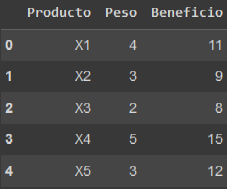


In [ ]:
modelo10 = LpProblem(name='Variables_binarias', sense=LpMaximize)

#Variables
I1 = LpVariable('I_1', lowBound=0, cat='Binary')
I2 = LpVariable('I_2', lowBound=0, cat='Binary')
I3 = LpVariable('I_3', lowBound=0, cat='Binary')
I4 = LpVariable('I_4', lowBound=0, cat='Binary')
I5 = LpVariable('I_5', lowBound=0, cat='Binary')


#Restricciones
modelo10 += 12*I1 + 9*I2 + 6*I3 + 15*I4 + 10*I5  <= 20

# Restricciones

# Si el producto 5 está incluído el 2 también
modelo10 += I2 >= I5


#  Si se colocan más de 2 productos hay un costo extra de $10

#modelo10 +=

#Si se coloca el producto 2, hay un bono extra de $8

#modelo10 +=

#Si se coloca el producto 3 o el producto 5, se debe colocar el producto 1 o el producto 2

#modelo10 +=

#Funcional
modelo10 += 11*I1 + 9*I2 + 8*I3 + 15*I4 + 12*I5

# Resuelvo
modelo10.solve()

for i in [I1,I2,I3,I4,I5]:
  print(f'{i} = {i.varValue:.0f}')

print()
print(f'Valor de la función objetivo es de: {modelo10.objective.value():.0f}')

I_1 = 0
I_2 = 1
I_3 = 0
I_4 = 0
I_5 = 1

Valor de la función objetivo es de: 21




---



# Extra

# Sensibilidad

In [ ]:
# Inicializo la clase
modelo11 = LpProblem("Parametrización", LpMaximize)

# Defino las variables
A = LpVariable('A', lowBound=0, cat='Continuous')
B = LpVariable('B', lowBound=0, cat='Continuous')
C = LpVariable('C', lowBound=0, cat='Continuous')

# Funcional
modelo11 += 500 * A + 450 * B + 600 * C

# Restricciones
modelo11 +=    6 * A + 5  * B +  8 * C <= 60, "Restricción 1"
modelo11 += 10.5 * A + 20 * B + 10 * C <= 150, "Restricción 2"
modelo11 +=        A                   <= 10,  "Restricción 3"



# Resuelvo el modelo
modelo11.solve()

print(f'Estatus del modelo tatus: {LpStatus[modelo11.status]}')
print()
print(f'Se obtiene un beneficio de = {value(modelo11.objective):.0f}')
print()
print('Las variables tienen los valores de:')
for v in modelo11.variables():
    print(v.name, "=", v.varValue)

Estatus del modelo tatus: Optimal

Se obtiene un beneficio de = 5133

Las variables tienen los valores de:
A = 6.6666667
B = 4.0
C = 0.0


In [ ]:
o = [{'nombre':nombre, 'precio sombra':c.pi,'slack': c.slack} for nombre, c in modelo11.constraints.items()]

print(pd.DataFrame(o))


          nombre  precio sombra     slack
0  Restricción_1      78.148148 -0.000000
1  Restricción_2       2.962963 -0.000000
2  Restricción_3      -0.000000  3.333333



  
  
# ¡ Suerte en la programación !

